<a href="https://colab.research.google.com/github/vijaysudhakar12/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import package

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.utils import resample


2. Load the DataSet

In [ ]:
df = pd.read_csv(r'/content/sample_data/customer_churn_classification_dataset.csv')
df.head()

,customer_id,age,gender,tenure,monthly_charges,total_charges,contract_type,payment_method,tech_support,online_security,internet_service,number_of_complaints,churn
0,C0001,56,Female,21,39.14,800.22,Two Year,Bank Transfer,No,Yes,Fiber,3,No
1,C0002,69,Female,43,68.95,3039.66,One Year,Credit Card,No,Yes,Fiber,1,Yes
2,C0003,46,Male,57,118.19,6713.41,One Year,UPI,No,No,Fiber,0,No
3,C0004,32,Female,35,70.92,2395.07,Monthly,Credit Card,Yes,No,Fiber,1,No
4,C0005,60,Female,68,107.04,7319.68,Monthly,Debit Card,No,Yes,No Internet,2,No


3. Check the Shape,Info and Null Value

In [ ]:
df.shape

(1008, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           1008 non-null   object 
 1   age                   1008 non-null   int64  
 2   gender                993 non-null    object 
 3   tenure                1008 non-null   int64  
 4   monthly_charges       996 non-null    float64
 5   total_charges         998 non-null    float64
 6   contract_type         1008 non-null   object 
 7   payment_method        1000 non-null   object 
 8   tech_support          998 non-null    object 
 9   online_security       1000 non-null   object 
 10  internet_service      1008 non-null   object 
 11  number_of_complaints  1008 non-null   int64  
 12  churn                 1008 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 102.5+ KB


In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,15
tenure,0
monthly_charges,12
total_charges,10
contract_type,0
payment_method,8
tech_support,10
online_security,8


4. Check Duplicate And Remove Duplicate

In [ ]:
df.duplicated().sum()

np.int64(8)

In [ ]:
df = df.drop_duplicates()

df.isnull().sum()

,0
customer_id,0
age,0
gender,15
tenure,0
monthly_charges,12
total_charges,10
contract_type,0
payment_method,8
tech_support,10
online_security,8


5. Handling Missing Value

Mean

In [ ]:
#For our dataset of ~1000 rows, removing 10–20 rows generally isn't a big problem.

print(df[['payment_method', 'gender']].isnull().mean() * 100)

# 1. Drop rows where 'payment_method' is NaN (keeps same column name)
df = df.dropna(subset=['payment_method','gender'])

df.info()



payment_method    0.8
gender            1.5
dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 978 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           978 non-null    object 
 1   age                   978 non-null    int64  
 2   gender                978 non-null    object 
 3   tenure                978 non-null    int64  
 4   monthly_charges       966 non-null    float64
 5   total_charges         968 non-null    float64
 6   contract_type         978 non-null    object 
 7   payment_method        978 non-null    object 
 8   tech_support          968 non-null    object 
 9   online_security       971 non-null    object 
 10  internet_service      978 non-null    object 
 11  number_of_complaints  978 non-null    int64  
 12  churn                 978 non-null    object 
dtypes: float64(2), int64(3), object(8)
memory usage: 107.0+ KB


In [ ]:
# This will now work perfectly since dul_rem is a full DataFrame again
df['monthly_charges'] = df['monthly_charges'].fillna(df['monthly_charges'].mean())

# View your updated DataFrame
df.head()


,customer_id,age,gender,tenure,monthly_charges,total_charges,contract_type,payment_method,tech_support,online_security,internet_service,number_of_complaints,churn
0,C0001,56,Female,21,39.14,800.22,Two Year,Bank Transfer,No,Yes,Fiber,3,No
1,C0002,69,Female,43,68.95,3039.66,One Year,Credit Card,No,Yes,Fiber,1,Yes
2,C0003,46,Male,57,118.19,6713.41,One Year,UPI,No,No,Fiber,0,No
3,C0004,32,Female,35,70.92,2395.07,Monthly,Credit Card,Yes,No,Fiber,1,No
4,C0005,60,Female,68,107.04,7319.68,Monthly,Debit Card,No,Yes,No Internet,2,No


Median

In [ ]:
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

In [ ]:
df['tech_support'].unique()

array(['No', 'Yes', nan], dtype=object)

Mode

In [ ]:
mode_value=df[df['tech_support'].notna()]['tech_support'].mode()[0]
df['tech_support']=df['tech_support'].fillna(mode_value)

mode_value=df[df['online_security'].notna()]['online_security'].mode()[0]
df['online_security']=df['online_security'].fillna(mode_value)

print(df.shape)
df.isnull().sum()

(978, 13)


,0
customer_id,0
age,0
gender,0
tenure,0
monthly_charges,0
total_charges,0
contract_type,0
payment_method,0
tech_support,0
online_security,0


6. Outlier detection And Handling Outlier

In [ ]:
def Find_outliers(df,col):
    minimum,Q1,median,Q3,maximum=np.quantile(df[col],[0,0.25,0.50,0.75,1.0])
    print("minimum:",minimum,"  Quartile_1: ",Q1," Median: ",median," Quartile_3: ",Q3," Maximum: ",maximum)
    IQR=Q3-Q1
    print("Interquartile Range: ",IQR)
    lower_fence=Q1-1.5*(IQR)
    higher_fence=Q3+1.5*(IQR)
    print("Lower Fence: ",lower_fence,"Higher Fence: ",higher_fence)
    df = df[(df[col] >= lower_fence) & (df[col] <= higher_fence)]
    print(df.shape)
    sns.boxplot(df[col])
    return df

<Axes: ylabel='monthly_charges'>

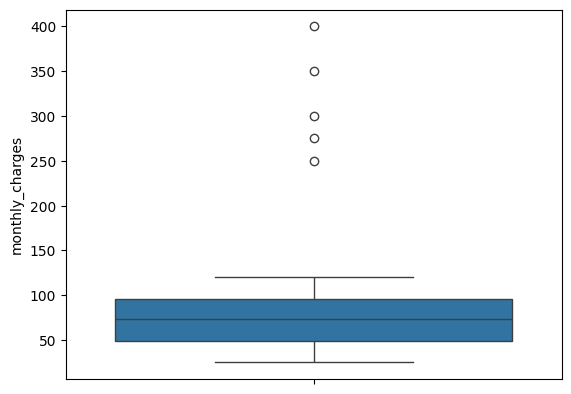

In [ ]:
sns.boxplot(df['monthly_charges'])

minimum: 25.0   Quartile_1:  49.19  Median:  73.64098861283642  Quartile_3:  96.0625  Maximum:  400.0
Interquartile Range:  46.8725
Lower Fence:  -21.118750000000006 Higher Fence:  166.37125
(973, 13)


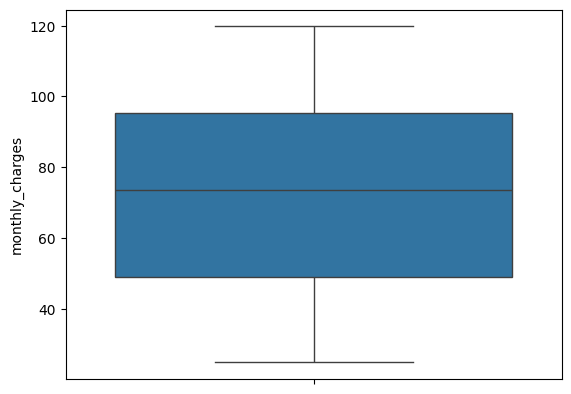

In [ ]:
df = Find_outliers(df,'monthly_charges')

<Axes: ylabel='total_charges'>

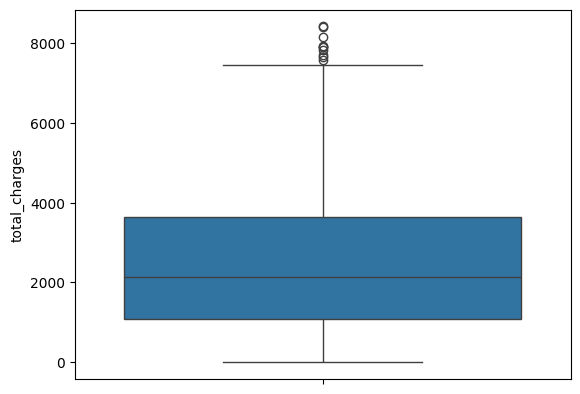

In [ ]:
sns.boxplot(df['total_charges'])

minimum: 0.0   Quartile_1:  1078.11  Median:  2129.95  Quartile_3:  3650.31  Maximum:  8411.42
Interquartile Range:  2572.2
Lower Fence:  -2780.1899999999996 Higher Fence:  7508.61
(963, 13)


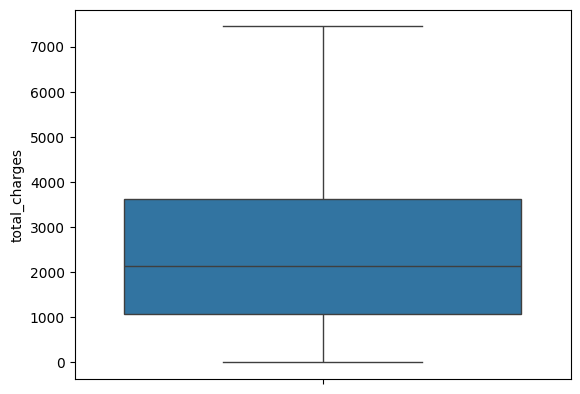

In [ ]:
df = Find_outliers(df,'total_charges')

In [ ]:
df['contract_type'].unique()

array(['Two Year', 'One Year', 'Monthly'], dtype=object)

In [ ]:
df['payment_method'].unique()

array(['Bank Transfer', 'Credit Card', 'UPI', 'Debit Card'], dtype=object)

In [ ]:
df['internet_service'].unique()

array(['Fiber', 'No Internet', 'DSL'], dtype=object)

7. Data Encoding

One-Hot Encoding

In [ ]:
def one_encode(df,col):
    encoder = OneHotEncoder()

    encoded = encoder.fit_transform(df[[col]]).toarray()

    encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

    df = df.reset_index(drop=True)

    df = pd.concat([df, encoder_df], axis=1)

    df = df.drop(columns=col)

    return df

In [ ]:
df_new = one_encode(df,'contract_type')
df_new = one_encode(df_new,'payment_method')
df_new = one_encode(df_new,'internet_service')


df_new.head()

,customer_id,age,gender,tenure,monthly_charges,total_charges,tech_support,online_security,number_of_complaints,churn,contract_type_Monthly,contract_type_One Year,contract_type_Two Year,payment_method_Bank Transfer,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,internet_service_DSL,internet_service_Fiber,internet_service_No Internet
0,C0001,56,Female,21,39.14,800.22,No,Yes,3,No,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,C0002,69,Female,43,68.95,3039.66,No,Yes,1,Yes,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,C0003,46,Male,57,118.19,6713.41,No,No,0,No,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,C0004,32,Female,35,70.92,2395.07,Yes,No,1,No,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,C0005,60,Female,68,107.04,7319.68,No,Yes,2,No,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


8. convert category to Numerical

In [ ]:
df_new['gender'] = df_new['gender'].map({'Female': 0,'Male':1})
df_new['tech_support'] = df_new['tech_support'].map({'No': 0,'Yes':1})
df_new['online_security'] = df_new['online_security'].map({'No': 0,'Yes':1})
df_new['churn'] = df_new['churn'].map({'No': 0,'Yes':1})
df_new = df_new.drop('customer_id',axis=1)

df_new.head()

,age,gender,tenure,monthly_charges,total_charges,tech_support,online_security,number_of_complaints,churn,contract_type_Monthly,contract_type_One Year,contract_type_Two Year,payment_method_Bank Transfer,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,internet_service_DSL,internet_service_Fiber,internet_service_No Internet
0,56,0,21,39.14,800.22,0,1,3,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,69,0,43,68.95,3039.66,0,1,1,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,46,1,57,118.19,6713.41,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,32,0,35,70.92,2395.07,1,0,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,60,0,68,107.04,7319.68,0,1,2,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           963 non-null    int64  
 1   gender                        963 non-null    int64  
 2   tenure                        963 non-null    int64  
 3   monthly_charges               963 non-null    float64
 4   total_charges                 963 non-null    float64
 5   tech_support                  963 non-null    int64  
 6   online_security               963 non-null    int64  
 7   number_of_complaints          963 non-null    int64  
 8   churn                         963 non-null    int64  
 9   contract_type_Monthly         963 non-null    float64
 10  contract_type_One Year        963 non-null    float64
 11  contract_type_Two Year        963 non-null    float64
 12  payment_method_Bank Transfer  963 non-null    float64
 13  payme

In [ ]:
df_new['churn'].value_counts()

,count
churn,
0,693
1,270


In [ ]:
df_new['churn'] = df_new.pop('churn')

9. Train Test split and Class imbalance and oversampling

In [ ]:

X = df_new.drop(columns=['churn'])
y = df_new['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)

df_minority = train_data[train_data['churn'] == 1]
df_majority = train_data[train_data['churn'] == 0]

print("Before Oversampling:")
print(train_data['churn'].value_counts())

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

train_upsampled = pd.concat([
    df_majority,
    df_minority_upsampled
])

Before Oversampling:
churn
0    554
1    216
Name: count, dtype: int64


In [ ]:
train_upsampled = train_upsampled.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train_upsampled = train_upsampled.drop('churn', axis=1)
y_train_upsampled = train_upsampled['churn']

print("\nAfter Oversampling:")
print(y_train_upsampled.value_counts())


After Oversampling:
churn
1    554
0    554
Name: count, dtype: int64


10. Feature Scaling

In [ ]:
scaler = StandardScaler()
# scaler_x_train = scaler.fit_transform(X_train_upsampled)
# scaler_x_test = scaler.transform(X_test)

# # NOTE: Scikit-learn scalers strip column names and return NumPy arrays.
# # To keep your DataFrame format, convert it back like this:
# X_train_scaled_df = pd.DataFrame(scaler_x_train, columns=X_train_upsampled.columns)
# X_test_scaled_df = pd.DataFrame(scaler_x_test, columns=X_test.columns)

X_train_scaled = scaler.fit_transform(X_train_upsampled)


# Apply same scaler to test data

X_test_scaled = scaler.transform(X_test)

11.  Train KNN Model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=6,metric='euclidean')
knn.fit(
    X_train_scaled,
    y_train_upsampled
)

KNeighborsClassifier(metric='euclidean', n_neighbors=6)

12. Predict

In [ ]:
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.76      0.78       139
           1       0.45      0.52      0.48        54

    accuracy                           0.69       193
   macro avg       0.63      0.64      0.63       193
weighted avg       0.70      0.69      0.70       193



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[105  34]
 [ 26  28]]
